<a href="https://colab.research.google.com/github/walji123/data-analysis-practical-assignment/blob/main/Social_Media_Engagement_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Social Media Engagement Analysis
# Objective
Analyze engagement patterns across social media platforms using likes, comments, shares, and content types.
## Key Question
What factors drive social media engagement across platforms and content types?

Table of contents:

Dataset Overview

Data Cleaning

Descriptive Statistics

Platform Analysis

Content Type Analysis

Visualizations

Insights

Reflection

In [111]:
import os
os.makedirs("data", exist_ok=True)

In [112]:
import shutil

shutil.copy(
    "/content/drive/MyDrive/python_projects/social_media_engagement1.csv",
    "data/social_media_engagement1.csv"
)

'data/social_media_engagement1.csv'

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("data/social_media_engagement1.csv")

In [114]:
df.head()

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive


In [115]:
df.columns

Index(['post_id', 'platform', 'post_type', 'post_time', 'likes', 'comments',
       'shares', 'post_day', 'sentiment_score'],
      dtype='object')

In [116]:
df.shape

(100, 9)

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   post_id          100 non-null    int64 
 1   platform         100 non-null    object
 2   post_type        100 non-null    object
 3   post_time        100 non-null    object
 4   likes            100 non-null    int64 
 5   comments         100 non-null    int64 
 6   shares           100 non-null    int64 
 7   post_day         100 non-null    object
 8   sentiment_score  100 non-null    object
dtypes: int64(4), object(5)
memory usage: 7.2+ KB


In [118]:
df.describe(include='all')

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
count,100.000000,100,100,100,100.000000,100.00000,100.000000,100,100
unique,NaN,3,5,99,NaN,NaN,NaN,7,3
top,NaN,Instagram,carousel,5/2/2023 6:15,NaN,NaN,NaN,Wednesday,positive
freq,NaN,36,26,2,NaN,NaN,NaN,18,46
mean,50.500000,NaN,NaN,NaN,2381.810000,202.66000,415.650000,NaN,NaN
std,29.011492,NaN,NaN,NaN,1632.573284,138.84067,283.877601,NaN,NaN
min,1.000000,NaN,NaN,NaN,15.000000,10.00000,16.000000,NaN,NaN
25%,25.750000,NaN,NaN,NaN,895.750000,89.75000,183.000000,NaN,NaN
50%,50.500000,NaN,NaN,NaN,2220.000000,171.00000,356.500000,NaN,NaN
75%,75.250000,NaN,NaN,NaN,3593.250000,299.00000,689.500000,NaN,NaN


Task 2 answers:
1. There are 100 rows and 9 columns in this dataset.
2. The columns post_id, comments, shares, and likes are all integers. While the columns platform, post_type, post_time, post_day, and sentiment_score are all objects.

In [119]:
df.isnull().sum()

,0
post_id,0
platform,0
post_type,0
post_time,0
likes,0
comments,0
shares,0
post_day,0
sentiment_score,0


# No missing values detected in this dataset.

In [120]:
df['platform'].unique()
df['post_type'].unique()
df['sentiment_score'].unique()

array(['positive', 'neutral', 'negative'], dtype=object)

In [121]:
df['platform'] = df['platform'].str.lower()
print(df['platform'])


0      facebook
1      facebook
2     instagram
3       twitter
4       twitter
        ...    
95    instagram
96      twitter
97      twitter
98    instagram
99    instagram
Name: platform, Length: 100, dtype: object


# There was no inconsistent formatting found during this process of conversion.



In [122]:
df['platform'].value_counts()

,count
platform,
instagram,36
facebook,32
twitter,32


# The most used social media platform in this engagement dataset is Instagram.

In [123]:
df['likes'].mean()

np.float64(2381.81)

In [124]:
df['likes'].median()

2220.0

In [125]:
df['likes'].max()

5000

In [126]:
df['likes'].min()

15

In [127]:
group_variable = 'shares'
ave_shares = df.groupby('platform')['shares'].mean()
print(ave_shares)

platform
facebook     474.375000
instagram    525.166667
twitter      233.718750
Name: shares, dtype: float64


# Instagram has the highest average shares, suggesting stronger content sharing behavior on that platform.


#Engagement Metric
Engagement was defined as the sum of likes, comments, and shares for each post.

In [128]:
df["engagement"] = df["likes"] + df["shares"] + df["comments"]
df.groupby("post_type")["engagement"].mean()

,engagement
post_type,
carousel,3030.730769
image,2601.470588
poll,3746.384615
text,2228.619048
video,3542.782609


# Poll posts have the highest average engagement across all platforms, suggesting that interactive content drives stronger user response.

In [129]:
df.sort_values(by='likes', ascending=False).head(5)


,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score,engagement
23,24,instagram,carousel,1/1/2023 20:00,5000,80,399,Sunday,positive,5479
35,36,facebook,video,4/8/2023 19:15,5000,500,43,Saturday,positive,5543
47,48,facebook,video,3/22/2023 3:15,5000,232,16,Wednesday,negative,5248
38,39,facebook,video,1/1/2023 6:00,5000,430,980,Sunday,neutral,6410
74,75,facebook,video,7/26/2023 20:15,5000,500,404,Wednesday,positive,5904


Among the five posts with the most likes, 4 of them were Facebook videos.

<Axes: title={'center': 'Average Likes by Platform'}, xlabel='Platform', ylabel='Average Likes'>

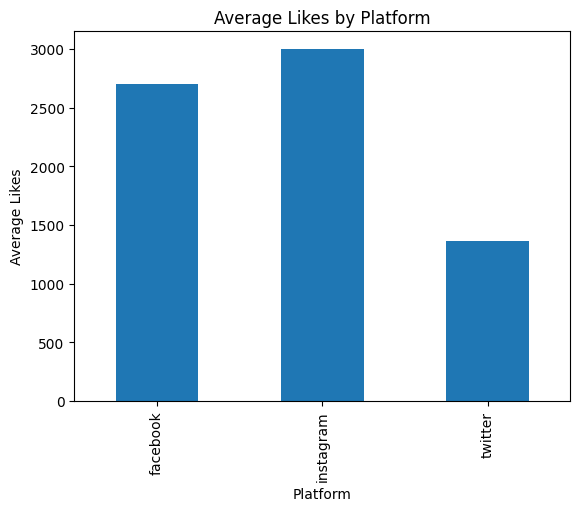

In [130]:
df.groupby('platform')['likes'].mean().plot(
    kind='bar',
    title='Average Likes by Platform',
    xlabel='Platform',
    ylabel='Average Likes'
)

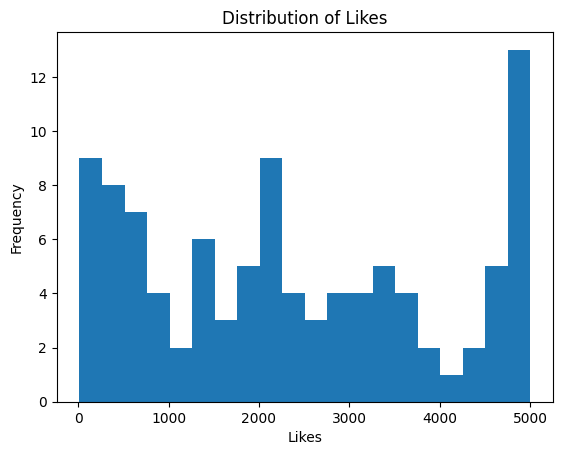

In [131]:
df['likes'].plot(
    kind='hist',
    bins=20,
    title='Distribution of Likes',
    xlabel='Likes'
)
plt.show()

Final Insights:


Insight 1: Facebook videos dominate top-liked posts, suggesting strong video performance on that platform.

Insight 2: Instagram has the highest average shares, indicating stronger content sharing behavior.

Insight 3: Poll posts show the highest average engagement, suggesting interactive content performs best overall.


---



Reflection:

Most surprising pattern:
Poll posts outperform other content types in engagement, even though videos dominate top likes.

Next analysis:
I would analyze the impact of posting time and sentiment score on engagement levels.